In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import pandas as pd 
import matplotlib.pyplot as plt

from banco import conectar 

conexao = conectar()

In [3]:
sql = """
SELECT tipo_pagamento, AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""
df = pd.read_sql(sql, conexao)
df

,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.280299
1,PASSAGEM,1878.344393
2,Serviço correlato: seguro,447.514653
3,RESTITUIÇÃO,245.702610


In [4]:
pd.read_sql(
    """
    SELECT
        MIN(data_inicio) AS primeira_data,
        MAX(data_inicio) AS ultima_data
    FROM silver_viagem
    """,
    conexao
)

,primeira_data,ultima_data
0,2025-01-01,2025-06-30


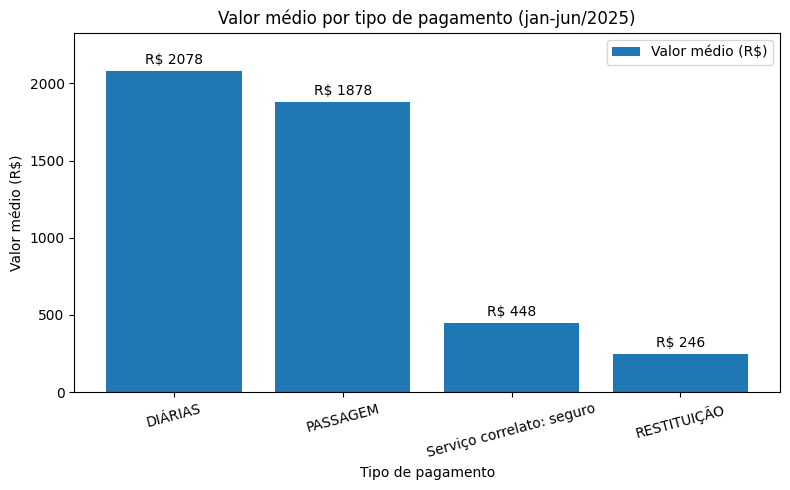

In [5]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    df["tipo_pagamento"],
    df["valor_medio"],
    label="Valor médio (R$)"
)

plt.bar_label(
    barras,
    fmt="R$ %.0f",
    padding=3
)

plt.title("Valor médio por tipo de pagamento (jan-jun/2025)")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")
plt.legend()
plt.xticks(rotation=15)

plt.ylim(0, df["valor_medio"].max() * 1.12)
plt.tight_layout()
plt.show()

In [6]:
df_ordenado = df.sort_values(
    "valor_medio",
    ascending=False
).reset_index(drop=True)

maior = df_ordenado.iloc[0]
segundo = df_ordenado.iloc[1]

percentual_acima = (
    (maior["valor_medio"] - segundo["valor_medio"])
    / segundo["valor_medio"]
) * 100

print(f"Maior categoria: {maior['tipo_pagamento']}")
print(f"Maior média: R$ {maior['valor_medio']:.2f}")
print(f"Segundo colocado: {segundo['tipo_pagamento']}")
print(f"Segunda média: R$ {segundo['valor_medio']:.2f}")
print(f"Percentual acima: {percentual_acima:.1f}%")

Maior categoria: DIÁRIAS
Maior média: R$ 2078.28
Segundo colocado: PASSAGEM
Segunda média: R$ 1878.34
Percentual acima: 10.6%


### Resposta

O tipo de pagamento com maior valor médio é **DIÁRIAS**, com **R$ 2.078,28 por
pagamento**, aproximadamente **10,6% acima de PASSAGEM**, o segundo colocado.

### Leitura

**DIÁRIAS** e **PASSAGEM** ficam muito acima dos demais, com valores médios de
**R$ 2.078,28** e **R$ 1.878,34**, respectivamente. Os outros dois tipos têm
valores bem menores: **R$ 447,51** para serviço correlato (seguro) e
**R$ 245,70** para restituição.

Isso indica que diárias e passagens são os pagamentos individuais mais altos,
enquanto seguro e restituição são valores acessórios, de menor porte.

> Observação: a média mostra o valor de um pagamento típico, não o peso de cada
> tipo no gasto total, que dependeria também de quantos pagamentos existem de
> cada tipo.

In [7]:
conexao.rollback()

sql = """
SELECT meio_transporte, COUNT(*) AS total
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY total DESC;
"""
df = pd.read_sql(sql, conexao)
df

,meio_transporte,total
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


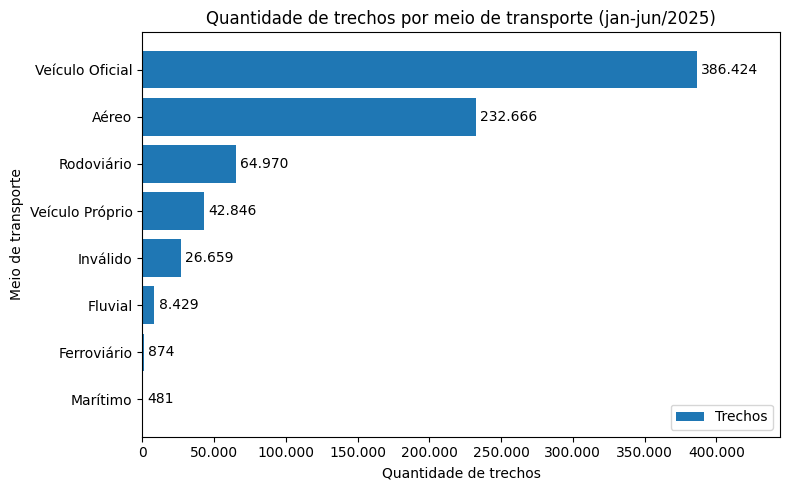

In [8]:
plt.figure(figsize=(8, 5))

barras = plt.barh(
    df["meio_transporte"],
    df["total"],
    label="Trechos"
)

rotulos = [
    f"{valor:,.0f}".replace(",", ".")
    for valor in df["total"]
]

plt.bar_label(
    barras,
    labels=rotulos,
    padding=3
)

plt.title(
    "Quantidade de trechos por meio de transporte (jan-jun/2025)"
)

plt.xlabel("Quantidade de trechos")
plt.ylabel("Meio de transporte")
plt.legend()

plt.gca().invert_yaxis()

plt.xlim(
    0,
    df["total"].max() * 1.15
)

from matplotlib.ticker import FuncFormatter

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)
plt.tight_layout()
plt.show()

### Resposta

O meio de transporte mais usado nos trechos é o **Veículo Oficial**, com
**386.424 trechos** (cerca de **50,6%** do total), à frente do **Aéreo**, com
**232.666 trechos** (30,5%).

### Leitura

Os dois primeiros meios concentram cerca de **81%** dos 763.349 trechos, e o
Veículo Oficial tem aproximadamente **66% mais trechos** que o Aéreo. Os demais
(rodoviário, veículo próprio, fluvial, ferroviário e marítimo) têm participação
pequena, e os meios ferroviário e marítimo somam menos de 0,2%.

A categoria **"Inválido"** soma **26.659 trechos** (3,5%) e já vem assim da
fonte, o que indica registros sem meio de transporte válido nos dados
originais.

In [9]:
sql = """
SELECT
    id_viagem,
    nome_viajante,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 5
"""

df_maiores_viagens = pd.read_sql(sql, conexao)

df_maiores_viagens

,id_viagem,nome_viajante,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,384,0.0
1,0000000000020793594,Informações protegidas por sigilo,379,120650.0
2,0000000000020774569,CLAUDIA ADRIANA DA SILVA,370,0.0
3,0000000000020793492,Informações protegidas por sigilo,370,113382.5
4,0000000000020592696,RAILANA BERENICE AMORAS OLIVEIRA,367,159044.9


In [10]:
sql = """
SELECT id_viagem, nome_viajante, data_inicio, data_fim, duracao_dias,
       valor_diarias, valor_passagens, valor_outros_gastos,
       valor_devolucao, valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 5;
"""
df = pd.read_sql(sql, conexao)
df

,id_viagem,nome_viajante,data_inicio,data_fim,duracao_dias,valor_diarias,valor_passagens,valor_outros_gastos,valor_devolucao,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,2025-01-13,2026-01-31,384,0.0,0.0,0.0,0.0,0.0
1,0000000000020793594,Informações protegidas por sigilo,2025-01-02,2026-01-15,379,120650.0,0.0,0.0,0.0,120650.0
2,0000000000020774569,CLAUDIA ADRIANA DA SILVA,2025-02-26,2026-03-02,370,0.0,0.0,0.0,0.0,0.0
3,0000000000020793492,Informações protegidas por sigilo,2025-01-11,2026-01-15,370,113382.5,0.0,0.0,0.0,113382.5
4,0000000000020592696,RAILANA BERENICE AMORAS OLIVEIRA,2025-01-01,2026-01-02,367,128107.5,30937.4,0.0,0.0,159044.9


In [11]:
sql = """
SELECT id_viagem, SUM(valor) AS total_pago
FROM silver_pagamento
WHERE id_viagem IN ('0000000000020699856', '0000000000020774569')
GROUP BY id_viagem;
"""
pd.read_sql(sql, conexao)

,id_viagem,total_pago


In [12]:
plt.figure(figsize=(7, 3.5))
barras = plt.barh(nomes, df["duracao_dias"], label="Duração (dias)")
plt.bar_label(barras, labels=rotulos, padding=3, fontsize=8)

plt.title("As 5 viagens de maior duração e seu custo total (jan-jun/2025)",
          fontsize=10)
plt.xlabel("Duração (dias)", fontsize=9)
plt.ylabel("Viagem (final do identificador)", fontsize=9)
plt.tick_params(labelsize=8)
plt.legend(loc="lower right", fontsize=8)

plt.gca().invert_yaxis()
plt.xlim(0, df["duracao_dias"].max() * 1.6)
plt.tight_layout()
plt.show()

NameError: name 'nomes' is not defined

<Figure size 700x350 with 0 Axes>

### Resposta

A viagem de maior duração é a de **Luisangela Correa Franco de Faria**, com
**384 dias** e custo total de **R$ 0,00**.

### Leitura

As cinco viagens mais longas ficam entre **367 e 384 dias**. Todas passam de
um ano porque os dados são filtrados pela **data de início** (jan-jun/2025),
e o fim pode cair em 2026.

Duração e custo não andam juntos: a mais longa e a terceira (Claudia, 370 dias)
têm custo zero, e as duas não têm nenhum pagamento registrado na tabela de
pagamentos. O motivo não aparece nos dados, e pode ser uma viagem sem custo
para o órgão ou um registro não preenchido na fonte. A mais cara das cinco,
de **Railana (R$ 159.044,90)**, é a quinta em duração. Duas das cinco têm o
nome protegido por sigilo.

In [ ]:
from banco import conectar, executar

executar(conexao, "DROP TABLE IF EXISTS gold_custo_orgao")

executar(
    conexao,
    """
    CREATE TABLE gold_custo_orgao AS
    SELECT
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
        SUM(p.valor) AS total_pago
    FROM silver_viagem v
    JOIN silver_pagamento p
        ON v.id_viagem = p.id_viagem
    GROUP BY v.nome_orgao_superior
    """
)

In [ ]:
df_gold = pd.read_sql(
    """
    SELECT *
    FROM gold_custo_orgao
    ORDER BY total_pago DESC
    LIMIT 5
    """,
    conexao
)
df_gold

,nome_orgao_superior,qtd_viagens,total_pago
0,Ministério da Justiça e Segurança Pública,75633,4.888311e+08
1,Ministério da Defesa,61388,1.565498e+08
2,Ministério da Educação,60011,1.118974e+08
3,Ministério do Meio Ambiente e Mudança do Clima,13397,5.012304e+07
4,Ministério da Previdência Social,7911,4.065949e+07


In [ ]:
df_gold.style.format({
    "total_pago": "R$ {:,.2f}",
    "qtd_viagens": "{:,.0f}"
})

,nome_orgao_superior,qtd_viagens,total_pago
0,Ministério da Justiça e Segurança Pública,"75,633","R$ 488,831,110.61"
1,Ministério da Defesa,"61,388","R$ 156,549,767.91"
2,Ministério da Educação,"60,011","R$ 111,897,434.35"
3,Ministério do Meio Ambiente e Mudança do Clima,"13,397","R$ 50,123,043.80"
4,Ministério da Previdência Social,"7,911","R$ 40,659,494.63"


In [ ]:
executar(
    conexao,
    """
    CREATE OR REPLACE VIEW vw_custo_orgao AS
    SELECT
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
        SUM(p.valor) AS total_pago
    FROM silver_viagem v
    JOIN silver_pagamento p
        ON v.id_viagem = p.id_viagem
    GROUP BY v.nome_orgao_superior
    """
)

In [ ]:
df_view = pd.read_sql(
    """
    SELECT *
    FROM vw_custo_orgao
    ORDER BY total_pago DESC
    LIMIT 5
    """,
    conexao
)

df_view

,nome_orgao_superior,qtd_viagens,total_pago
0,Ministério da Justiça e Segurança Pública,75633,4.888311e+08
1,Ministério da Defesa,61388,1.565498e+08
2,Ministério da Educação,60011,1.118974e+08
3,Ministério do Meio Ambiente e Mudança do Clima,13397,5.012304e+07
4,Ministério da Previdência Social,7911,4.065949e+07


In [ ]:
df_view_formatado = df_view.copy()

df_view_formatado["qtd_viagens"] = df_view_formatado["qtd_viagens"].apply(
    lambda valor: f"{valor:,.0f}".replace(",", ".")
)

df_view_formatado["total_pago"] = df_view_formatado["total_pago"].apply(
    lambda valor: (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )
)

df_view_formatado

,nome_orgao_superior,qtd_viagens,total_pago
0,Ministério da Justiça e Segurança Pública,75.633,"R$ 488.831.110,61"
1,Ministério da Defesa,61.388,"R$ 156.549.767,91"
2,Ministério da Educação,60.011,"R$ 111.897.434,35"
3,Ministério do Meio Ambiente e Mudança do Clima,13.397,"R$ 50.123.043,80"
4,Ministério da Previdência Social,7.911,"R$ 40.659.494,63"


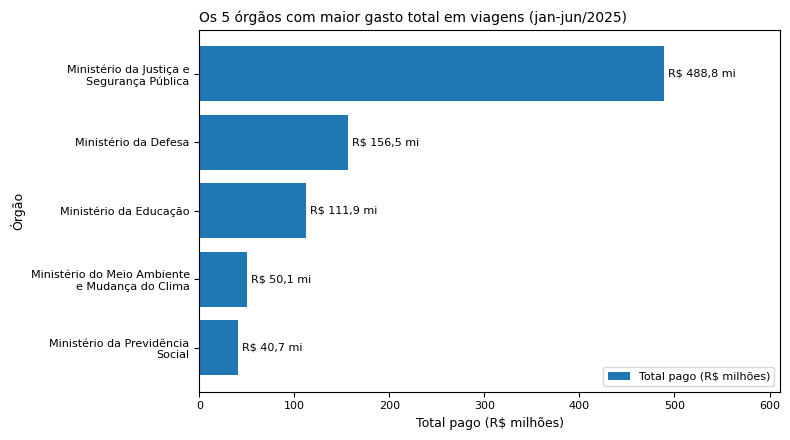

In [ ]:
import textwrap

df_view = pd.read_sql(
    """
    SELECT *
    FROM vw_custo_orgao
    ORDER BY total_pago DESC
    LIMIT 5
    """,
    conexao
)

nomes = [textwrap.fill(n, 28) for n in df_view["nome_orgao_superior"]]
valores_mi = df_view["total_pago"] / 1_000_000

plt.figure(figsize=(8, 4.5))
barras = plt.barh(nomes, valores_mi, label="Total pago (R$ milhões)")

rotulos = [
    f"R$ {v:,.1f} mi".replace(",", "X").replace(".", ",").replace("X", ".")
    for v in valores_mi
]
plt.bar_label(barras, labels=rotulos, padding=3, fontsize=8)

plt.title(
    "Os 5 órgãos com maior gasto total em viagens (jan-jun/2025)",
    fontsize=10,
    loc="left"
)
plt.xlabel("Total pago (R$ milhões)", fontsize=9)
plt.ylabel("Órgão", fontsize=9)
plt.tick_params(labelsize=8)
plt.legend(loc="lower right", fontsize=8)

plt.gca().invert_yaxis()
plt.xlim(0, valores_mi.max() * 1.25)
plt.tight_layout()
plt.show()

In [13]:
pd.read_sql(
    """
    SELECT
        ROUND(
            100.0 * SUM(total_pago) FILTER (
                WHERE total_pago >= 111000000
            ) / SUM(total_pago),
            1
        ) AS pct_top3
    FROM gold_custo_orgao
    """,
    conexao
)

,pct_top3
0,63.4


In [14]:
df_custo_viagem = pd.read_sql(
    """
    SELECT
        nome_orgao_superior,
        qtd_viagens,
        total_pago,
        ROUND(total_pago / qtd_viagens, 2) AS pago_por_viagem
    FROM gold_custo_orgao
    ORDER BY total_pago DESC
    LIMIT 5
    """,
    conexao
)

df_custo_viagem

,nome_orgao_superior,qtd_viagens,total_pago,pago_por_viagem
0,Ministério da Justiça e Segurança Pública,75633,4.888311e+08,6463.20
1,Ministério da Defesa,61388,1.565498e+08,2550.17
2,Ministério da Educação,60011,1.118974e+08,1864.62
3,Ministério do Meio Ambiente e Mudança do Clima,13397,5.012304e+07,3741.36
4,Ministério da Previdência Social,7911,4.065949e+07,5139.62


### Resposta

O órgão com maior gasto total em viagens foi o **Ministério da Justiça e Segurança Pública**, com aproximadamente **R$ 488,8 milhões** entre janeiro e junho de 2025.

### Leitura

O Ministério da Justiça e Segurança Pública aparece muito à frente dos demais, com aproximadamente **R$ 488,8 milhões**, seguido pelo Ministério da Defesa, com **R$ 156,5 milhões**. O gasto da Justiça foi cerca de **3,1 vezes maior** que o do segundo colocado.

Os três primeiros órgãos — Ministério da Justiça e Segurança Pública, Ministério da Defesa e Ministério da Educação — concentram **63,4% do total pago** na tabela analisada.

Além de realizar a maior quantidade de viagens, o Ministério da Justiça também apresentou o maior valor médio pago por viagem entre os cinco órgãos, de **R$ 6.463,20**. Portanto, sua liderança no gasto total é explicada tanto pelo maior volume de viagens quanto pelo maior custo médio por viagem.